<a href="https://colab.research.google.com/github/fourmodern/2025_aidrugdiscovery/blob/main/Day3/T012_ADMET_hERG_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T012 · ADMET 특성 예측: hERG 심장독성 (baseline vs 딥러닝)

**참고:** 이 talktorial은 2025 AI 신약개발 워크숍 **Day 3(ADMET 특성 예측)** 실습 자료로,
TeachOpenCADD(볼카머 랩)의 talktorial 형식을 따라 구성했습니다.

작성:

* 2025 AI 신약개발 워크숍 · Day 3
* 형식·구성: TeachOpenCADD 스타일([_J. Cheminform._ 2019, **11**, 1-7](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x)) 참조

__Talktorial T012__: 이 talktorial은 Day 1(화학정보학·구조 기반 설계)·Day 2(생성·구조 AI)에 이어,
**약물의 ADMET 특성을 데이터로 예측**하는 파이프라인을 다룹니다. hERG 심장독성을 사례로,
데이터 정제부터 baseline(트리)과 딥러닝(그래프 신경망) 비교, 해석·불확실성까지 직접 구현합니다.

## 이 talktorial의 목표

약물이 심장 **hERG(KCNH2) 칼륨 채널**을 차단하면 QT 간격이 길어져 치명적 부정맥을 일으킬 수 있어,
신약 개발 초기부터 **hERG 차단 위험**을 예측·스크리닝합니다. 이 talktorial에서는 SMILES만으로
hERG 차단(양성/음성)을 예측하는 모델을 만들되, **데이터를 제대로 정제**한 뒤
**baseline(ECFP+XGBoost)** 와 **딥러닝(그래프 신경망, D-MPNN)** 을 **같은 조건(scaffold split)** 에서 비교하고,
**SHAP** 해석과 **conformal** 불확실성까지 붙입니다.

> 관통 메시지 — '어떤 모델이냐'보다 **'데이터를 어떻게 다듬고, 어떻게 검증했느냐'**.
> 소규모 ADMET에선 baseline이 딥러닝과 대등하거나 우위인 경우가 많다 — 직접 확인합니다.

### 이론 내용

* hERG 심장독성과 '특성 예측'
* 데이터: 출처와 정제
    * 여러 출처 (TDC·ChEMBL·PubChem·CSV)
    * 표준화·중복·상충 라벨 정리
* 분자 표현과 모델
    * 지문(ECFP) · descriptor
    * baseline(트리) vs 딥러닝(GNN, D-MPNN)
* 검증·해석·불확실성
    * scaffold split (구조 누수 방지)
    * 불균형 지표 (PR-AUC·MCC)
    * SHAP · conformal prediction

### 실습 내용

* 환경 설정
* 데이터 로드 (여러 출처, 하나의 인터페이스)
* 데이터 정제 (표준화·중복/상충 제거)
* featurize & scaffold split
* ① baseline — ECFP + XGBoost
* ② 딥러닝 — 그래프 신경망 (D-MPNN)
* 모델 비교 — baseline vs 딥러닝
* baseline 강화 & 새 분자 예측
* 해석 — SHAP
* 불확실성 — conformal

### 참고문헌

* Therapeutics Data Commons (TDC): Huang et al., [_NeurIPS_ (2021)](https://arxiv.org/abs/2102.09548) · [tdcommons.ai](https://tdcommons.ai)
* hERG 채널과 심장독성: Sanguinetti & Tristani-Firouzi, [_Nature_ **440**, 463–469 (2006)](https://doi.org/10.1038/nature04710)
* hERG_Karim 데이터셋(CardioTox): Karim et al., [_J. Cheminform._ **13**, 60 (2021)](https://doi.org/10.1186/s13321-021-00541-z)
* 분자 표준화: [RDKit MolStandardize](https://www.rdkit.org/docs/) (Cleanup·LargestFragment·Uncharger)
* 확장 연결성 지문 (ECFP): Rogers & Hahn, [_J. Chem. Inf. Model._ 50.5 (2010): 742-754](https://doi.org/10.1021/ci100050t)
* XGBoost: Chen & Guestrin, [_KDD_ (2016)](https://doi.org/10.1145/2939672.2939785)
* 그래프 신경망 (D-MPNN, Chemprop): Yang et al., [_J. Chem. Inf. Model._ 59.8 (2019): 3370-3388](https://doi.org/10.1021/acs.jcim.9b00237)
* Scaffold 분할: Bemis & Murcko, [_J. Med. Chem._ 39.15 (1996): 2887-2893](https://doi.org/10.1021/jm9602928)
* SHAP: Lundberg & Lee, [_NeurIPS_ (2017)](https://arxiv.org/abs/1705.07874)
* Conformal prediction (입문): Angelopoulos & Bates, [_Found. Trends ML_ (2023)](https://arxiv.org/abs/2107.07511)
* baseline vs 딥러닝 (ADMET): Jiang et al., [_J. Cheminform._ **13**, 12 (2021)](https://doi.org/10.1186/s13321-020-00479-8); 전향적 검증 Fang et al., [_J. Chem. Inf. Model._ (2023)](https://doi.org/10.1021/acs.jcim.3c00160)

## 이론

### hERG 심장독성과 '특성 예측'

**hERG(KCNH2)** 는 심장 재분극을 담당하는 K⁺ 채널이다. 약물이 이 채널을 차단하면 **QT 간격이 길어지고 →
치명적 부정맥** 위험이 생겨, hERG는 신약이 반드시 피해야 할 대표적 **off-target**이다.
'특성 예측'이란 **분자 구조(SMILES) → 실험으로 측정하던 특성(hERG 차단)** 을 모델이 대신 추정하는 일이며,
실험 assay 값이 '정답(label)'이 된다.

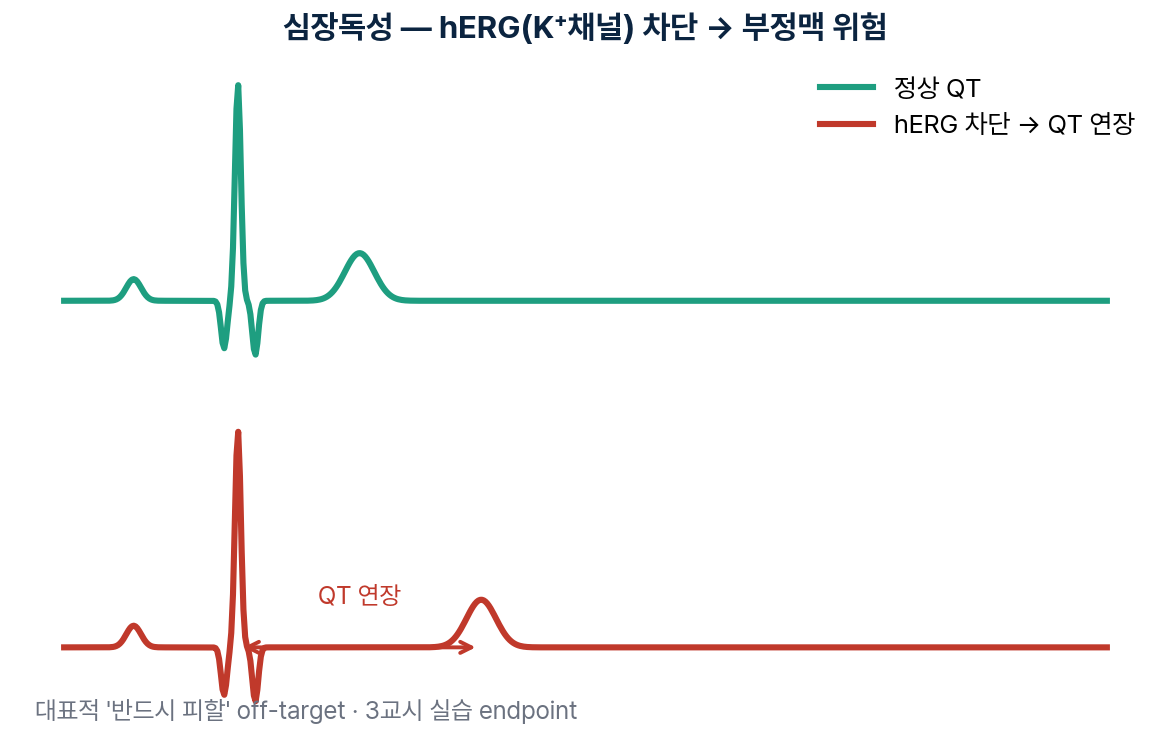


### 데이터: 출처와 정제

hERG 데이터의 원천은 **ChEMBL·문헌**이다. **TDC(Therapeutics Data Commons)** 는 이를 표준 split·지표로 감싼
벤치마크 래퍼일 뿐 — 유일한 출처가 아니다. 출처가 무엇이든 결국 `SMILES + 라벨`이면 같은 파이프라인이 돈다.

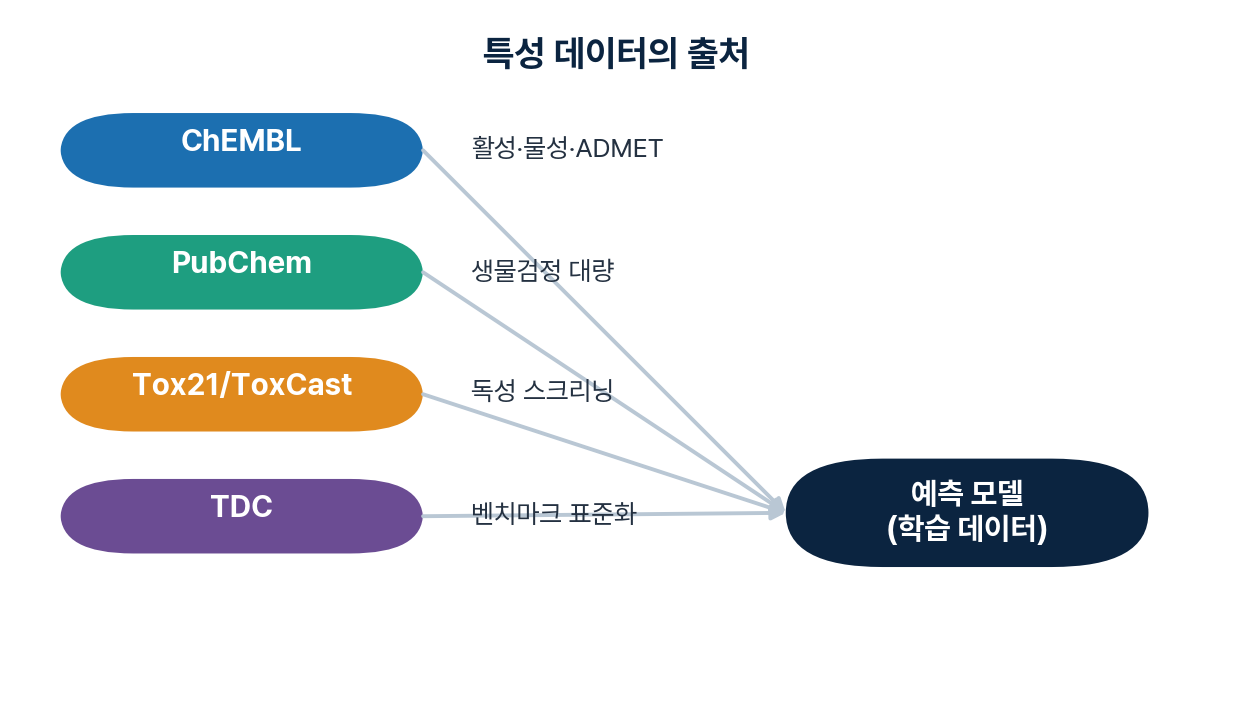

**모델보다 데이터가 먼저다.** 공개 데이터에는 **염·용매·이온화 형태 차이**, **중복 분자**,
**같은 분자에 상충되는 라벨**이 섞여 있다. 표준화(가장 큰 조각 선택·중화·canonical) 후 중복을 병합하고,
**라벨이 엇갈리는 분자는 버린다**(노이즈를 학습시키지 않기 위해).

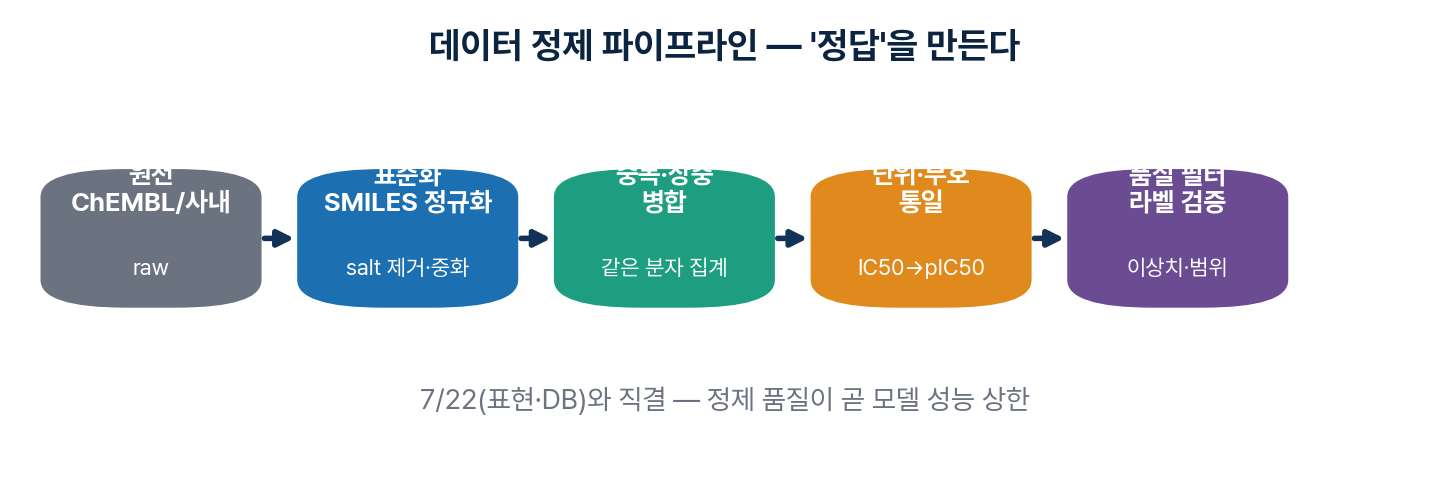


### 분자 표현과 모델 — baseline vs 딥러닝

**baseline**: 분자를 **ECFP4 지문**(반경2 Morgan, 부분구조 존재 비트)으로 숫자화 → **XGBoost**.
소규모/중간 ADMET에서 자주 최상위권인 강한 기준선이다.

**딥러닝**: 분자를 **그래프(원자=노드, 결합=엣지)** 로 보고, 결합을 따라 **메시지를 전달·집계(T회)** 한 뒤
분자 벡터로 모아 예측한다(**D-MPNN**). 표현을 데이터로 **학습**한다는 점이 baseline과 다르다.

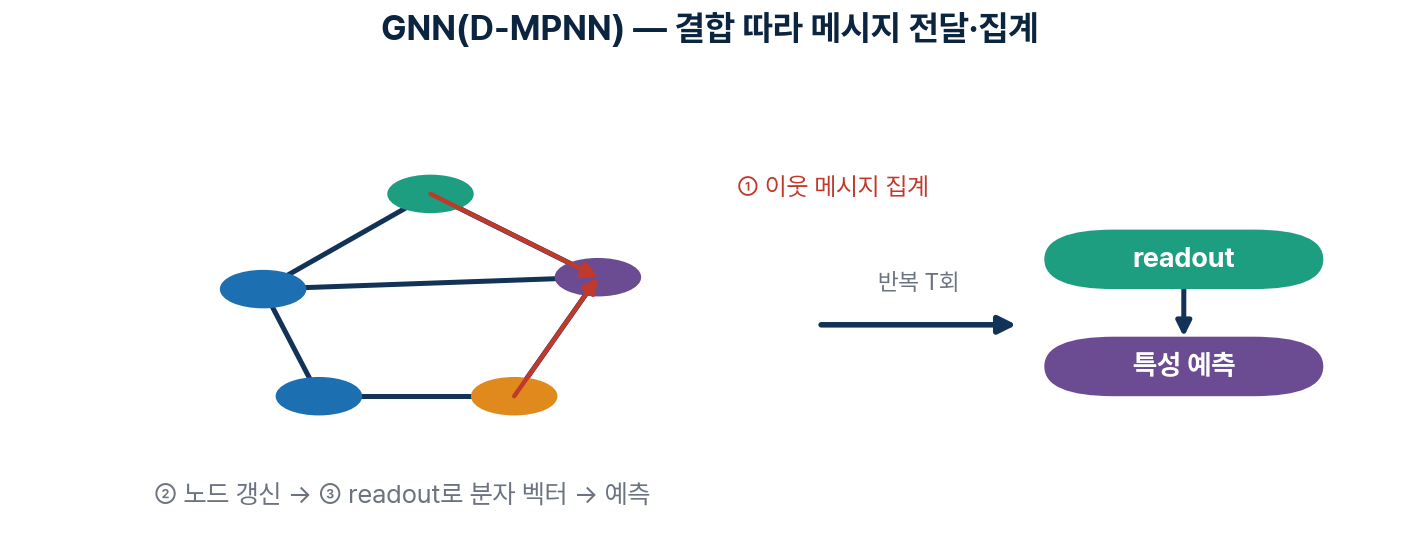

강의의 핵심 질문 — *딥러닝이 정말 baseline을 이기나?* 를 같은 데이터·같은 split에서 직접 확인한다.


### 검증·해석·불확실성

**scaffold split**: `random split`은 유사 분자가 train/test에 함께 들어가 성능을 부풀린다.
Bemis-Murcko 골격 기준으로 나눠 **신규 골격 일반화**를 현실적으로 추정한다.
**불균형 지표**: 정확도 대신 **PR-AUC·MCC·recall**. **해석(SHAP)** 으로 '왜', **conformal**로 '얼마나 믿나'를 붙인다.

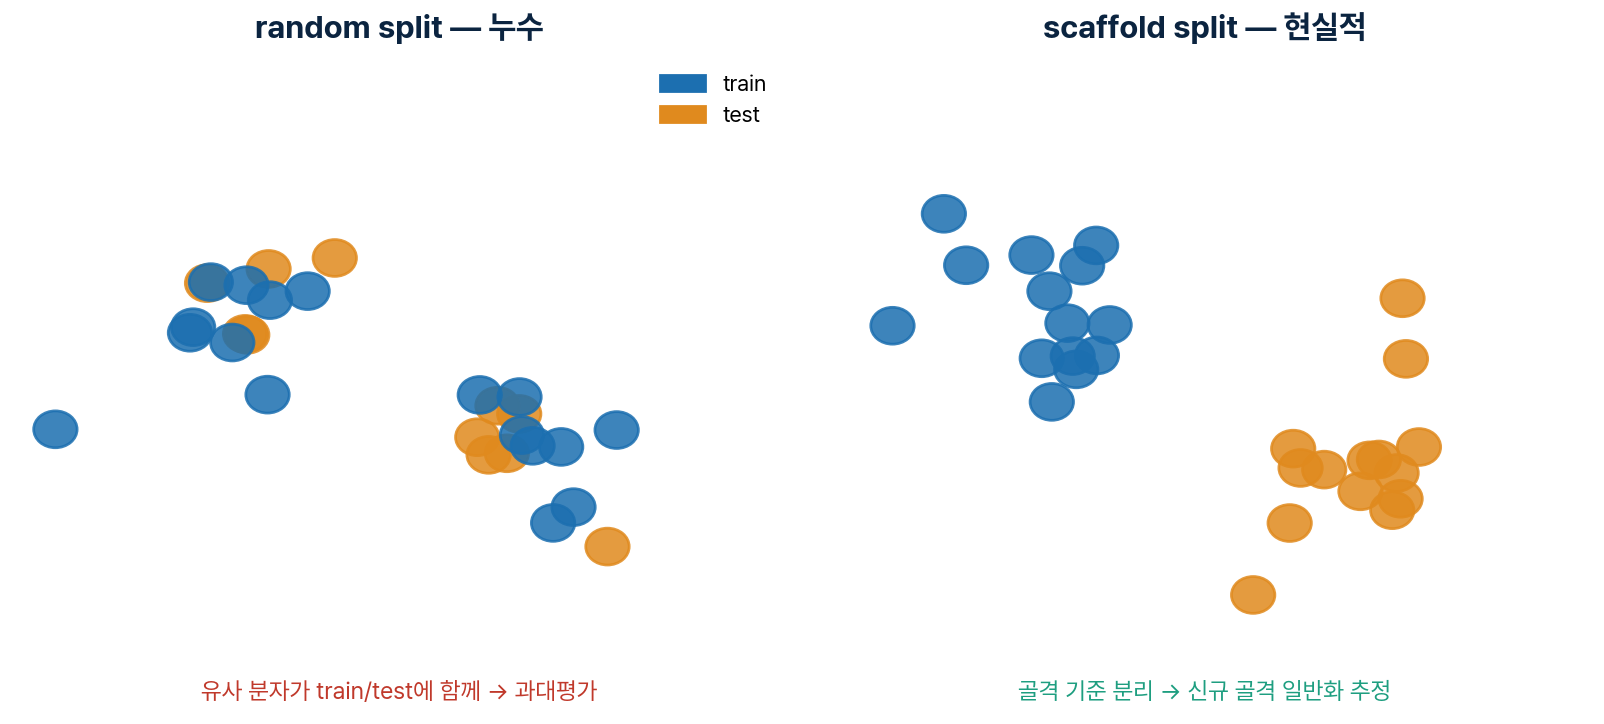


## 실습

첫 셀에서 필요한 패키지를 설치한다. GNN용 `torch`는 Colab에서 **런타임 > GPU**를 켜면 빨라진다(없어도 CPU로 동작).

In [1]:
!pip -q install rdkit xgboost scikit-learn shap torch
# (선택) TDC 로더: !pip -q install PyTDC   |  한글 그래프: !apt-get -qq install -y fonts-nanum

In [2]:
import os, io, time, urllib.request, numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
from rdkit import Chem, RDLogger; RDLogger.DisableLog("rdApp.*")
from rdkit.Chem import rdFingerprintGenerator, Descriptors, rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
import xgboost as xgb, torch, torch.nn as nn
from sklearn.metrics import (roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, precision_recall_curve, roc_curve)
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
for _c in ["/usr/share/fonts/truetype/pretendard/Pretendard-Regular.otf",
           "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
           "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"]:
    if os.path.exists(_c):
        fm.fontManager.addfont(_c); plt.rcParams["font.family"]=fm.FontProperties(fname=_c).get_name(); break
plt.rcParams["axes.unicode_minus"]=False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("준비 완료 · torch", torch.__version__, "· device", DEVICE)

준비 완료 · torch 2.13.0+cpu · device cpu


### 데이터 로드 (여러 출처, 하나의 인터페이스)

`PyTDC → dataverse 직접 다운로드 → CSV` 어느 경로든 `smiles+label`로 통일한다.
기본은 **hERG_Karim(≈13k, 균형)** — 작고 치우친 hERG(655)보다 깨끗한 학습에 유리하다.

In [3]:
DATAVERSE = {"hERG_Karim": 6822246,   # ≈13k, 균형(권장)
             "hERG_small": 4259588}   # 655, 소규모·불균형
def load_raw(which="hERG_Karim"):
    try:
        from tdc.single_pred import Tox
        name = "hERG_Karim" if which=="hERG_Karim" else "hERG"
        df = Tox(name=name).get_data(); src=f"PyTDC(Tox,'{name}')"
    except Exception:
        url=f"https://dataverse.harvard.edu/api/access/datafile/{DATAVERSE[which]}"
        raw=urllib.request.urlopen(urllib.request.Request(url,headers={"User-Agent":"Mozilla/5.0"}),timeout=90).read()
        df=pd.read_csv(io.BytesIO(raw),sep="\t"); src=f"Dataverse 직접({which})"
    df=df.rename(columns={"Drug":"smiles","Y":"label"})[["smiles","label"]]
    print("출처:", src, "· 원본", len(df), "행"); return df
raw = load_raw("hERG_Karim"); raw.head(3)

출처: Dataverse 직접(hERG_Karim) · 원본 13445 행


,smiles,label
0,Fc1ccc(-n2cc(NCCN3CCCCC3)nn2)cc1F,1
1,COc1cc(N2Cc3ccc(Sc4ccc(F)cc4)nc3C2=O)ccc1OCCN1...,0
2,CCOC(=O)[C@H]1CC[C@@H](N2CC(NC(=O)CNc3nn(C(N)=...,0


다른 출처로 바꾸려면 (참고 · 형식만 맞추면 이후 코드는 그대로):

In [4]:
# (A) CSV(사내 assay):  raw = pd.read_csv("my.csv").rename(columns={"SMILES":"smiles","hERG":"label"})[["smiles","label"]]
# (B) ChEMBL 웹 API (hERG=CHEMBL240):
#   !pip -q install chembl_webresource_client
#   from chembl_webresource_client.new_client import new_client
#   acts=new_client.activity.filter(target_chembl_id="CHEMBL240",standard_type="IC50").only(["canonical_smiles","standard_value"])
#   raw=pd.DataFrame([(a["canonical_smiles"], int(float(a["standard_value"])<10000)) for a in acts
#         if a["canonical_smiles"] and a["standard_value"]], columns=["smiles","label"])
# (C) 소규모 원본:  raw = load_raw("hERG_small")
print("참고 셀")

참고 셀


### 데이터 정제 (표준화·중복/상충 제거)

`표준화(salt 제거·중화·canonical) → 유효성 검사 → 중복 병합·상충 라벨 제거`.

원본 13445 → 표준화·유효 13445 → 상충 16개 제거 → 최종 13136 · 양성 50.0%


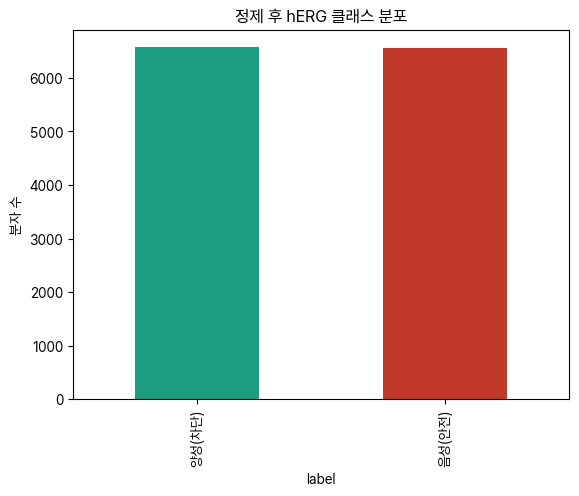

In [5]:
_lfc = rdMolStandardize.LargestFragmentChooser()   # 가장 큰 조각(=본체) → 염/용매 제거
_unc = rdMolStandardize.Uncharger()                # 중화
def standardize(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    try:
        m = rdMolStandardize.Cleanup(m); m = _lfc.choose(m); m = _unc.uncharge(m)
        return Chem.MolToSmiles(m)                  # canonical SMILES
    except Exception:
        return None
def clean_dataset(df):
    n0=len(df); df=df.copy(); df["can"]=df["smiles"].map(standardize)
    df=df.dropna(subset=["can"]); n_valid=len(df); df["label"]=df["label"].astype(int)
    g=df.groupby("can")["label"]; n_conflict=int((g.nunique()>1).sum())
    keep=g.nunique()[g.nunique()==1].index
    out=pd.DataFrame({"smiles":keep,"label":[int(g.mean()[k]) for k in keep]})
    print(f"원본 {n0} → 표준화·유효 {n_valid} → 상충 {n_conflict}개 제거 → 최종 {len(out)} · 양성 {out['label'].mean():.1%}")
    return out
df = clean_dataset(raw)
df["label"].value_counts().rename({0:"음성(안전)",1:"양성(차단)"}).plot(
    kind="bar", color=["#1E9E80","#C0392B"]); plt.title("정제 후 hERG 클래스 분포"); plt.ylabel("분자 수"); plt.show()

### featurize & scaffold split

In [6]:
_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def featurize(smiles):
    X, keep = [], []
    for i, smi in enumerate(smiles):
        m = Chem.MolFromSmiles(smi)
        if m is None: continue
        X.append(_gen.GetFingerprintAsNumPy(m)); keep.append(i)
    return np.asarray(X), keep
def scaffold_split(df, frac_train=0.8, seed=42):
    import random, collections
    buckets = collections.defaultdict(list)
    for i, smi in enumerate(df["smiles"]):
        try: sc = MurckoScaffold.MurckoScaffoldSmiles(smiles=smi, includeChirality=False)
        except Exception: sc = ""
        buckets[sc].append(i)
    groups = list(buckets.values()); random.Random(seed).shuffle(groups)
    n_train = int(frac_train*len(df)); tr, te = [], []
    for g in groups: (tr if len(tr)+len(g) <= n_train else te).extend(g)
    return df.iloc[tr].reset_index(drop=True), df.iloc[te].reset_index(drop=True)
train_df, test_df = scaffold_split(df, 0.8)
Xtr, ktr = featurize(train_df["smiles"]); ytr = train_df["label"].values[ktr]
Xte, kte = featurize(test_df["smiles"]);  yte = test_df["label"].values[kte]
print(f"train {len(ytr)} · test {len(yte)} · train 양성비 {ytr.mean():.1%}")

train 10508 · test 2628 · train 양성비 50.6%


### ① baseline — ECFP + XGBoost

소규모/중간 ADMET의 **강한 기준선**. 불균형은 `scale_pos_weight`로 보정한다.

In [7]:
spw = (ytr==0).sum() / max((ytr==1).sum(), 1)
clf = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
        eval_metric="aucpr", random_state=42).fit(Xtr, ytr)
p_base = clf.predict_proba(Xte)[:,1]
def report(name, y, p):
    print(f"[{name}]  ROC-AUC {roc_auc_score(y,p):.3f} · PR-AUC {average_precision_score(y,p):.3f} "
          f"· MCC {matthews_corrcoef(y,(p>=0.5).astype(int)):.3f}")
report("baseline XGBoost", yte, p_base)

[baseline XGBoost]  ROC-AUC 0.836 · PR-AUC 0.824 · MCC 0.504


### ② 딥러닝 — 그래프 신경망 (D-MPNN)

분자를 그래프로 보고 결합을 따라 메시지를 전달·집계한 뒤 분자 벡터로 모아 예측한다(PyTorch로 직접 구현).

In [8]:
# 분자 → 그래프 featurize
_ATOMS=[5,6,7,8,9,15,16,17,35,53]
def atom_feat(a):
    z=a.GetAtomicNum(); f=[int(z==x) for x in _ATOMS]+[int(z not in _ATOMS)]
    f+=[int(a.GetDegree()==d) for d in range(5)]+[int(a.GetTotalNumHs()==h) for h in range(5)]
    f+=[int(a.GetFormalCharge()==c) for c in (-1,0,1)]+[int(a.GetIsAromatic()),int(a.IsInRing())]
    return f
_NF=len(atom_feat(Chem.MolFromSmiles("C").GetAtomWithIdx(0)))
_BT={Chem.BondType.SINGLE:0,Chem.BondType.DOUBLE:1,Chem.BondType.TRIPLE:2,Chem.BondType.AROMATIC:3}
def mol_graph(smi):
    m=Chem.MolFromSmiles(smi)
    if m is None or m.GetNumAtoms()==0: return None
    x=torch.tensor([atom_feat(a) for a in m.GetAtoms()],dtype=torch.float)
    src,dst,et=[],[],[]
    for b in m.GetBonds():
        i,j=b.GetBeginAtomIdx(),b.GetEndAtomIdx(); t=_BT.get(b.GetBondType(),0)
        src+=[i,j]; dst+=[j,i]; et+=[t,t]
    if not src: src,dst,et=[0],[0],[0]
    return x, torch.tensor([src,dst]), torch.tensor(et)
def to_batch(graphs):
    xs,eis,ebs,batch=[],[],[],[]; off=0
    for k,(x,ei,eb) in enumerate(graphs):
        xs.append(x); eis.append(ei+off); ebs.append(eb); batch+=[k]*x.size(0); off+=x.size(0)
    return (torch.cat(xs).to(DEVICE),torch.cat(eis,1).to(DEVICE),torch.cat(ebs).to(DEVICE),torch.tensor(batch).to(DEVICE))
class GNN(nn.Module):
    def __init__(s,nf,h=64,T=3):
        super().__init__(); s.T=T; s.emb=nn.Linear(nf,h); s.et=nn.Embedding(4,h)
        s.msg=nn.Linear(h,h); s.upd=nn.GRUCell(h,h)
        s.out=nn.Sequential(nn.Linear(h,h),nn.ReLU(),nn.Dropout(0.1),nn.Linear(h,1))
    def forward(s,x,ei,eb,batch,nmol):
        h=torch.relu(s.emb(x)); src,dst=ei
        for _ in range(s.T):
            m=s.msg(h)[src]*torch.sigmoid(s.et(eb))                 # 이웃 메시지(결합종류 게이트)
            h=s.upd(torch.zeros_like(h).index_add_(0,dst,m), h)     # 집계 → GRU 갱신
        pool=torch.zeros(nmol,h.size(1),device=h.device).index_add_(0,batch,h)
        cnt=torch.zeros(nmol,1,device=h.device).index_add_(0,batch,torch.ones(h.size(0),1,device=h.device)).clamp(min=1)
        return s.out(pool/cnt).squeeze(1)                          # 평균 풀링 → 예측
print("GNN 준비 · 원자 특징차원", _NF)

GNN 준비 · 원자 특징차원 26


In [9]:
def prep(d):
    g=[mol_graph(s) for s in d["smiles"]]; keep=[i for i,x in enumerate(g) if x is not None]
    return [g[i] for i in keep], torch.tensor(d["label"].values[keep],dtype=torch.float)
trg, ytr_t = prep(train_df); teg, yte_g = prep(test_df)
torch.manual_seed(42); net=GNN(_NF).to(DEVICE); opt=torch.optim.Adam(net.parameters(),lr=1e-3)
pos=ytr_t.mean(); lossf=nn.BCEWithLogitsLoss(pos_weight=torch.tensor((1-pos)/pos).to(DEVICE))
idx=np.arange(len(trg)); EPOCHS=30; t0=time.time()
for ep in range(EPOCHS):
    net.train(); np.random.default_rng(ep).shuffle(idx)
    for i in range(0,len(idx),128):
        gb=[trg[j] for j in idx[i:i+128]]; yb=ytr_t[idx[i:i+128]].to(DEVICE)
        x,ei,eb,batch=to_batch(gb); opt.zero_grad()
        loss=lossf(net(x,ei,eb,batch,len(gb)),yb); loss.backward(); opt.step()
    if (ep+1)%10==0: print(f"  epoch {ep+1}/{EPOCHS}  loss {loss.item():.3f}")
print(f"GNN 학습 완료 · {time.time()-t0:.0f}s ({DEVICE})")
net.eval(); ps=[]
with torch.no_grad():
    for i in range(0,len(teg),256):
        x,ei,eb,batch=to_batch(teg[i:i+256]); ps.append(torch.sigmoid(net(x,ei,eb,batch,len(teg[i:i+256]))).cpu())
p_gnn=torch.cat(ps).numpy(); report("GNN (D-MPNN)", yte_g.numpy(), p_gnn)

  epoch 10/30  loss 0.558


  epoch 20/30  loss 0.592


  epoch 30/30  loss 0.635
GNN 학습 완료 · 162s (cpu)


[GNN (D-MPNN)]  ROC-AUC 0.753 · PR-AUC 0.736 · MCC 0.331


### 모델 비교 — baseline vs 딥러닝 (같은 split)

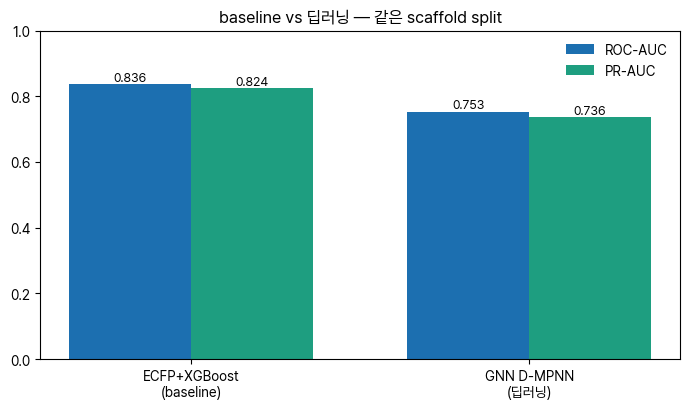

→ 소규모/중간 ADMET에서 즉석 GNN은 튜닝된 트리 baseline을 넘기 어렵다.
  GNN이 이기려면: 더 많은 데이터·하이퍼파라미터 튜닝·대규모 사전학습.


In [10]:
res={"ECFP+XGBoost\n(baseline)":(roc_auc_score(yte,p_base),average_precision_score(yte,p_base)),
     "GNN D-MPNN\n(딥러닝)":(roc_auc_score(yte_g.numpy(),p_gnn),average_precision_score(yte_g.numpy(),p_gnn))}
labels=list(res); roc=[res[k][0] for k in labels]; pr=[res[k][1] for k in labels]
x=np.arange(2); w=0.36; fig,ax=plt.subplots(figsize=(7,4.2))
ax.bar(x-w/2,roc,w,label="ROC-AUC",color="#1C6FB0"); ax.bar(x+w/2,pr,w,label="PR-AUC",color="#1E9E80")
for i in range(2):
    ax.text(x[i]-w/2,roc[i]+.01,f"{roc[i]:.3f}",ha="center",fontsize=9)
    ax.text(x[i]+w/2,pr[i]+.01,f"{pr[i]:.3f}",ha="center",fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0,1); ax.legend(frameon=False)
ax.set_title("baseline vs 딥러닝 — 같은 scaffold split"); plt.tight_layout(); plt.show()
print("→ 소규모/중간 ADMET에서 즉석 GNN은 튜닝된 트리 baseline을 넘기 어렵다.")
print("  GNN이 이기려면: 더 많은 데이터·하이퍼파라미터 튜닝·대규모 사전학습.")

### baseline 강화 & 새 분자 예측

MapLight 스타일(지문+descriptor)로 baseline을 강화하고, 학습된 모델로 임의 SMILES를 스코어링한다.

In [11]:
def featurize2(smiles):
    X,keep=[],[]
    for i,smi in enumerate(smiles):
        m=Chem.MolFromSmiles(smi)
        if m is None: continue
        ecfp=_gen.GetFingerprintAsNumPy(m)
        desc=np.array([Descriptors.MolWt(m),Descriptors.MolLogP(m),rdMolDescriptors.CalcTPSA(m),
                       Descriptors.NumHDonors(m),Descriptors.NumHAcceptors(m)],dtype=float)
        X.append(np.concatenate([ecfp,desc])); keep.append(i)
    return np.asarray(X),keep
Xtr2,_=featurize2(train_df["smiles"]); Xte2,_=featurize2(test_df["smiles"])
clf2=xgb.XGBClassifier(n_estimators=500,max_depth=6,learning_rate=0.05,subsample=0.8,
      colsample_bytree=0.8,scale_pos_weight=spw,eval_metric="aucpr",random_state=42).fit(Xtr2,ytr)
report("지문+descriptor", yte, clf2.predict_proba(Xte2)[:,1])
new={"nicotine":"CN1CCC[C@H]1c1cccnc1","aspirin":"CC(=O)Oc1ccccc1C(=O)O",
     "astemizole(양성 알려짐)":"COc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1"}
Xn,kn=featurize([standardize(s) or s for s in new.values()])
for (nm,_),r in zip(new.items(), clf.predict_proba(Xn)[:,1]): print(f"hERG 위험 {r:5.2f}   {nm}")

[지문+descriptor]  ROC-AUC 0.869 · PR-AUC 0.854 · MCC 0.584
hERG 위험  0.47   nicotine
hERG 위험  0.07   aspirin
hERG 위험  0.98   astemizole(양성 알려짐)


### 해석 — SHAP

어떤 부분구조가 위험을 올리/내리는지. 트리는 `TreeExplainer`로 빠르다.
(지문 비트 SHAP는 **부분구조로 역매핑**해야 해석 가능 — 상관 ≠ 인과.)

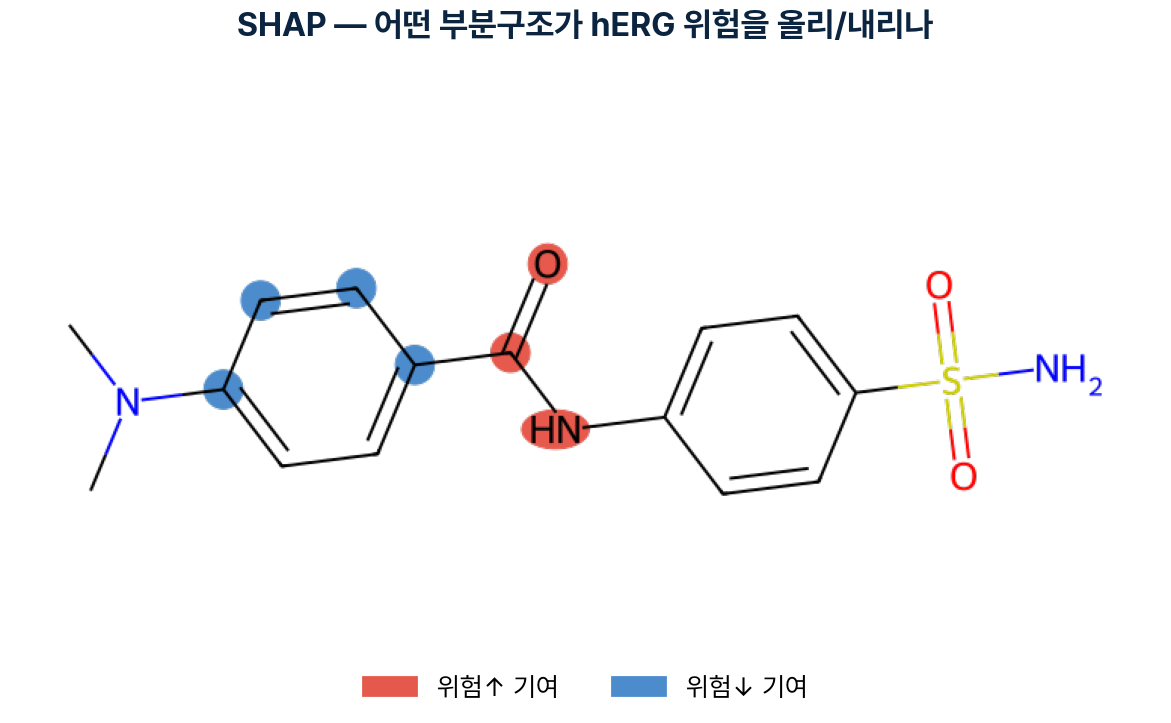


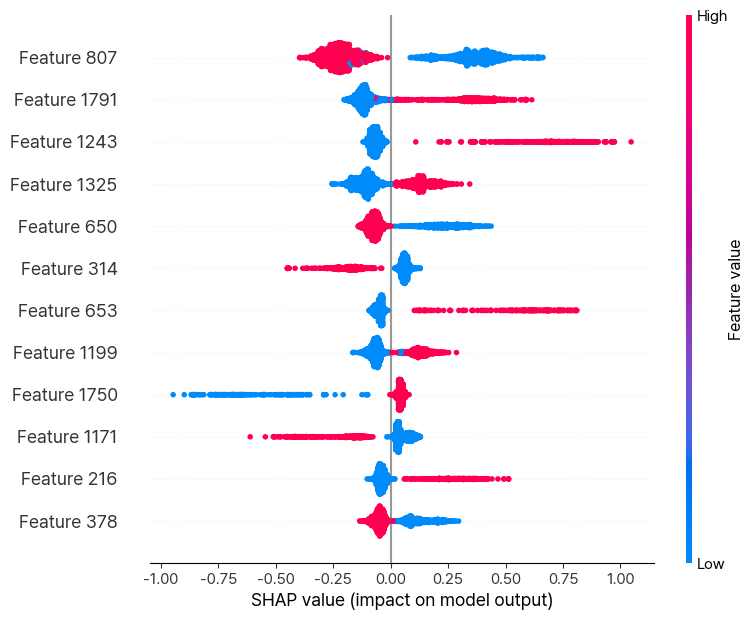

In [12]:
import shap
sv=shap.TreeExplainer(clf).shap_values(Xte)
shap.summary_plot(sv, Xte, max_display=12, show=True)

### 불확실성 — conformal 예측집합

보정셋으로 **목표 커버리지를 보장**하는 예측 '집합'. 집합이 `{0,1}` 둘 다면 '모른다' 신호.
(표준 도구: MAPIE — 여기선 split-conformal(LAC)을 직접 구현.)

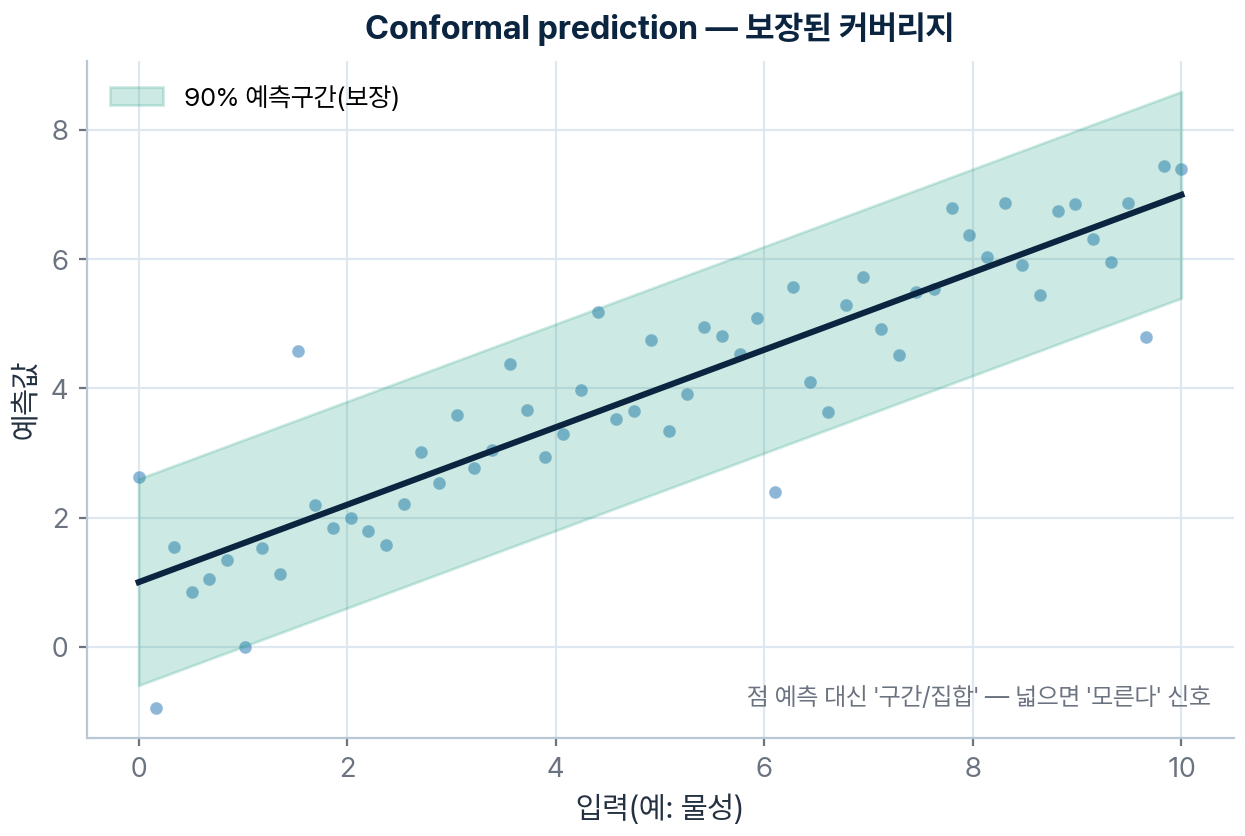


In [13]:
from sklearn.model_selection import train_test_split
Xc,Xcal,yc,ycal=train_test_split(Xtr,ytr,test_size=0.3,random_state=42,stratify=ytr)
cal=xgb.XGBClassifier(n_estimators=500,max_depth=6,learning_rate=0.05,subsample=0.8,
     colsample_bytree=0.8,scale_pos_weight=spw,eval_metric="aucpr",random_state=42).fit(Xc,yc)
alpha=0.1
sc=1-cal.predict_proba(Xcal)[np.arange(len(ycal)),ycal]
q=np.quantile(sc, np.ceil((len(ycal)+1)*(1-alpha))/len(ycal), method="higher")
sets=cal.predict_proba(Xte) >= (1-q)
cov=sets[np.arange(len(yte)),yte].mean(); size=sets.sum(1)
print(f"목표 커버리지 {1-alpha:.0%} · 실제 {cov:.1%} · 평균 집합크기 {size.mean():.2f}")
print(f"'모른다({{0,1}})' 비율 {(size==2).mean():.1%}")

목표 커버리지 90% · 실제 86.4% · 평균 집합크기 1.29
'모른다({0,1})' 비율 28.7%


## 토론

- **정제가 성능을 바꾼다.** 표준화·중복/상충 제거만으로도 라벨 노이즈가 줄어 학습이 안정된다.
  같은 분자에 라벨이 엇갈리는 데이터를 그대로 넣으면 모델이 노이즈를 외운다.
- **baseline이 강하다.** 같은 scaffold split에서 ECFP+XGBoost(및 +descriptor)가 즉석 GNN을 앞섰다.
  이는 소규모/중간 규모 ADMET에서 흔한 결과다 — 딥러닝은 **더 많은 데이터·튜닝·대규모 사전학습**이 있을 때 이득이 커진다.
  (여기 GNN은 교육용 최소 구현이며, Chemprop 같은 튜닝된 D-MPNN·사전학습을 쓰면 격차가 줄거나 역전될 수 있다.)
- **검증 방식이 결론을 만든다.** random split이었다면 두 모델 모두 더 높게 나왔을 것이다(누수). 배포에 가까운 검증은
  scaffold(또는 temporal) split이다.
- **점 예측만으론 부족하다.** conformal 예측집합의 `{0,1}`(모른다) 비율과 SHAP 해석을 함께 보고해야 현업에서 신뢰·채택된다.

**한계·다음 단계**: 다seed·다지표(PR-AUC·MCC)·신뢰구간 보고, Optuna 튜닝, Chemprop(정식 D-MPNN) 비교,
적용범위(AD)·MAPIE conformal, 다른 endpoint(용해도·CYP)로 확장.

## 퀴즈

1. 같은 분자에 **상충되는 라벨**(한 곳은 차단=1, 다른 곳은 0)이 있을 때, 이 실습에서는 어떻게 처리했고 왜 그렇게 했나요?
2. **random split** 대신 **scaffold split**을 쓰는 이유는 무엇이며, 각각에서 성능 숫자는 어느 쪽이 더 높게 나오는 경향이 있나요?
3. 이 실습에서 **baseline(XGBoost)** 이 **GNN**을 앞선 이유로 생각할 수 있는 것들을 데이터·모델·검증 관점에서 각각 하나씩 들어보세요.
4. 불균형 분류에서 **정확도(accuracy)** 대신 **PR-AUC·MCC**를 보는 이유는? conformal 예측집합이 `{0,1}`(둘 다)일 때의 의미는?